# Assignment 1
 Borgar, Oskar & Robert.

## Exploring the AmesHousing Dataset
We find the structure and basic information of the AmesHousing dataset using df.info() and a preview of the first few rows using df.head(). we find our target variable SalePrice as the last column. thats what we are trying to predict. we need to split the data into training and testing sets and keep them seperate


## 1. Load data and check its structure


In [93]:
import numpy as np
import pandas as pd

df = pd.read_csv("AmesHousing.csv")

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 2. Remove identifiers and split before detailed exploration


In [94]:

from sklearn.model_selection import train_test_split

# Keep the loaded df intact; remove identifiers from the modelling data.
model_data = df.drop(columns=["Order", "PID"]).copy()
training, testing = train_test_split(model_data, test_size=0.2, random_state=42)
training = training.copy()
testing = testing.copy()

# This is a category code, not a continuous measurement.
for data in (training, testing):
    data["MS SubClass"] = data["MS SubClass"].map(
        lambda value: str(value) if pd.notna(value) else np.nan
    )

train_df = training.copy()
train_df.head()


,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
381,20,RL,80.0,10400,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2009,WD,Family,152000
834,60,RL,NaN,28698,Pave,NaN,IR2,Low,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,6,2009,WD,Abnorml,185000
1898,90,RL,70.0,9842,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,101800
678,90,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,90000
700,190,RM,63.0,7627,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,94550


We see that `Order` and `PID` are unique identifiers for each row and do not provide predictive value for the target variable `SalePrice`. An 80/20 split is chosen to provide a sufficient amount of data for training while reserving a portion for validation. The random seed is fixed to ensure reproducibility of the results. The test set is reserved and not inspected during model development...

## 3. Explore the target on training data


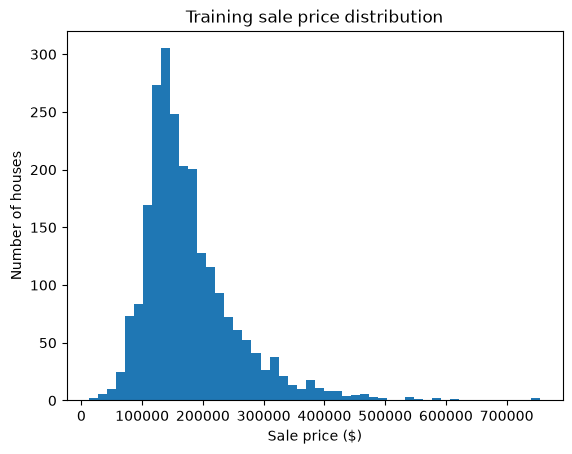

count      2344.000000
mean     178582.207765
std       77125.072713
min       12789.000000
25%      129000.000000
50%      160000.000000
75%      210000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [95]:
# lets first just get a look at the range of the target variable SalePrice
#creating a histogram to visualize the distribution of SalePrice
import matplotlib.pyplot as plt
plt.hist(train_df['SalePrice'], bins=50)
plt.title('Training sale price distribution')
plt.xlabel('Sale price ($)')
plt.ylabel('Number of houses')
plt.show()

train_df['SalePrice'].describe()

We see the distribution of the target variable SalePrice through the histogram and its summary statistics using df['SalePrice'].describe(). most of the prices center around the 160000 mark. There are also some higher-priced outliers that extend the range significantly.
we also observe that there are some extreme high-priced outliers. we will discuss this later when we consider data preprocessing and potential outlier treatment.

## 4. Missing values: count, explain, investigate


In [96]:
#lets check for missing values in the dataset and see which columns have them
missing_values_df = train_df.isnull().sum()
missing_values_df = missing_values_df[missing_values_df > 0]
missing_values_df = missing_values_df.sort_values(ascending=False)
missing_values_df

Pool QC           2332
Misc Feature      2250
Alley             2182
Fence             1874
Mas Vnr Type      1426
Fireplace Qu      1144
Lot Frontage       393
Garage Cond        122
Garage Yr Blt      122
Garage Finish      122
Garage Qual        122
Garage Type        120
Bsmt Exposure       63
BsmtFin Type 2      62
Bsmt Qual           61
BsmtFin Type 1      61
Bsmt Cond           61
Mas Vnr Area        19
BsmtFin SF 1         1
Bsmt Half Bath       1
Total Bsmt SF        1
Bsmt Full Bath       1
BsmtFin SF 2         1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

Just because the value is missing doesnt mean that its not important. in the guide for the dataset it made it clear that missing values often means that that entry does not have that particualr feature, e.g. pool qc. most of the houses do not have a pool, so the pool qc column will have many missing values. This is different from a missing value due to data collection errors, and should be treated accordingly. and many of the garage-related columns will have missing values for houses without garages, explaining the same value missing values in these columns.

In [97]:
missing_counts = train_df.isnull().sum()
missing_table = pd.DataFrame({"Missing count": missing_counts,"Missing (%)": (missing_counts / len(train_df) * 100).round(2),"Data type": train_df.dtypes.astype(str)})
missing_table = missing_table.loc[missing_counts > 0].sort_values("Missing count", ascending=False)
display(missing_table)


,Missing count,Missing (%),Data type
Pool QC,2332,99.49,str
Misc Feature,2250,95.99,str
Alley,2182,93.09,str
Fence,1874,79.95,str
Mas Vnr Type,1426,60.84,str
Fireplace Qu,1144,48.81,str
Lot Frontage,393,16.77,float64
Garage Cond,122,5.20,str
Garage Yr Blt,122,5.20,float64
Garage Finish,122,5.20,str




| Column/group | Meaning of missingness | Evidence/check | Planned treatment |
|---|---|---|---|
| Pool QC / Fireplace Qu | means no fireplace or pool | Compare Pool Area / Fireplaces | if area/fireplace is 0, label as absent, if not, use median of the respective feature |
| Alley / Fence / Misc Feature | no ally access / no fence / no misc feature | Dataset guide | label as absent |
| Garage categories | no garage | Garage Area and Garage Cars | label as absent |
| Basement categories | no basement | Total Bsmt SF | if area is 0, label as absent, if not, use default values in the garage or median of similar basements |
| Mas Vnr Type / Mas Vnr Area | if area is missing, no veneer, most of the type is missing and we just default to default | Original CSV tokens and area | label as absent, or if area is present, use the recorded values |
| Lot Frontage | unavailable | Guide | use median or estimate based on neighborhood |
| Garage Yr Blt | not recorded, similar count of missing values means there seems to be not a single actual missing value | Garage presence | use year of house or median of similar garages |


### lets check these




In [98]:
checks = {
    "Garage Qual": "Garage Area",
    "Pool QC": "Pool Area",
    "Fireplace Qu": "Fireplaces",
    "Bsmt Qual": "Total Bsmt SF",
    "Mas Vnr Type": "Mas Vnr Area"
}

for category, measurement in checks.items():
    values = train_df.loc[train_df[category].isna(), measurement]

    print(f"\nMissing {category}:")
    print("  Measurement is zero (likely absent):", values.eq(0).sum())
    print("  Measurement is positive (feature exists):", values.gt(0).sum())
    print("  Measurement also missing (unclear):", values.isna().sum())


Missing Garage Qual:
  Measurement is zero (likely absent): 120
  Measurement is positive (feature exists): 1
  Measurement also missing (unclear): 1

Missing Pool QC:
  Measurement is zero (likely absent): 2332
  Measurement is positive (feature exists): 0
  Measurement also missing (unclear): 0

Missing Fireplace Qu:
  Measurement is zero (likely absent): 1144
  Measurement is positive (feature exists): 0
  Measurement also missing (unclear): 0

Missing Bsmt Qual:
  Measurement is zero (likely absent): 60
  Measurement is positive (feature exists): 0
  Measurement also missing (unclear): 1

Missing Mas Vnr Type:
  Measurement is zero (likely absent): 1400
  Measurement is positive (feature exists): 7
  Measurement also missing (unclear): 19


We find that most of the categories with missing values correspond to features that are likely absent, as indicated by their related measurements being zero. This supports our planned treatment of labeling these features as absent when the related measurement is zero. we accept that all the 19 values ofmas vnr type is missing since there are 1400 absent likley cases....

## 5. Numerical relationships with SalePrice


## Correlations
LEts check the correlation between different features and the SalePrice to get a picture of some good predictors in the training set.

In [99]:
train_df = training.copy()
# Calculate correlations of all numeric features with SalePrice to identify strong predictors
correlations = (train_df.select_dtypes(include="number").corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False))

display(correlations.to_frame(name="Correlation with SalePrice"))

,Correlation with SalePrice
Overall Qual,0.795298
Gr Liv Area,0.698315
Garage Cars,0.644304
Garage Area,0.633106
Total Bsmt SF,0.612256
1st Flr SF,0.607433
Year Built,0.545409
Full Bath,0.542053
Year Remod/Add,0.517653
Garage Yr Blt,0.516211


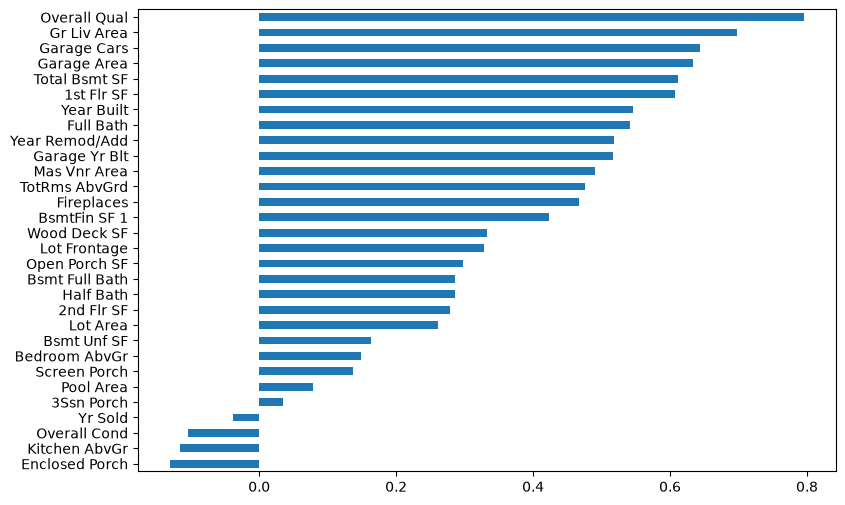

In [100]:
top = correlations.loc[correlations.abs().nlargest(30).index].sort_values()

plt.figure(figsize=(9, 6))
top.plot.barh()
plt.show()



we have identified the top 30 numerical features most correlated with SalePrice.

## 6. Categorical relationships with SalePrice


In [101]:
categorical_cols = training.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

# Include this house-type code even if it is still stored as numbers.
if "MS SubClass" not in categorical_cols:
    categorical_cols.append("MS SubClass")

print(f"{len(categorical_cols)} categorical columns:")
for col in categorical_cols:
    print(col)

44 categorical columns:
MS SubClass
MS Zoning
Street
Alley
Lot Shape
Land Contour
Utilities
Lot Config
Land Slope
Neighborhood
Condition 1
Condition 2
Bldg Type
House Style
Roof Style
Roof Matl
Exterior 1st
Exterior 2nd
Mas Vnr Type
Exter Qual
Exter Cond
Foundation
Bsmt Qual
Bsmt Cond
Bsmt Exposure
BsmtFin Type 1
BsmtFin Type 2
Heating
Heating QC
Central Air
Electrical
Kitchen Qual
Functional
Fireplace Qu
Garage Type
Garage Finish
Garage Qual
Garage Cond
Paved Drive
Pool QC
Fence
Misc Feature
Sale Type
Sale Condition


many categorical columns......

In [102]:
#fancy schmency table foir categorical features
tables = {}

for col in categorical_cols:
    tables[col] = (
        train_df.groupby(col, dropna=False, observed=True)["SalePrice"]
        .agg(["count", "median", "mean"])
        .sort_values("median", ascending=False)
        .round(0)
    )

combined = pd.concat(tables, names=["Feature", "Category"])

from IPython.display import HTML, display 

display(HTML(
    '<div style="max-height:600px; overflow:auto;">'
    + combined.to_html(float_format=lambda x: f"{x:,.0f}")
    + '</div>'
))

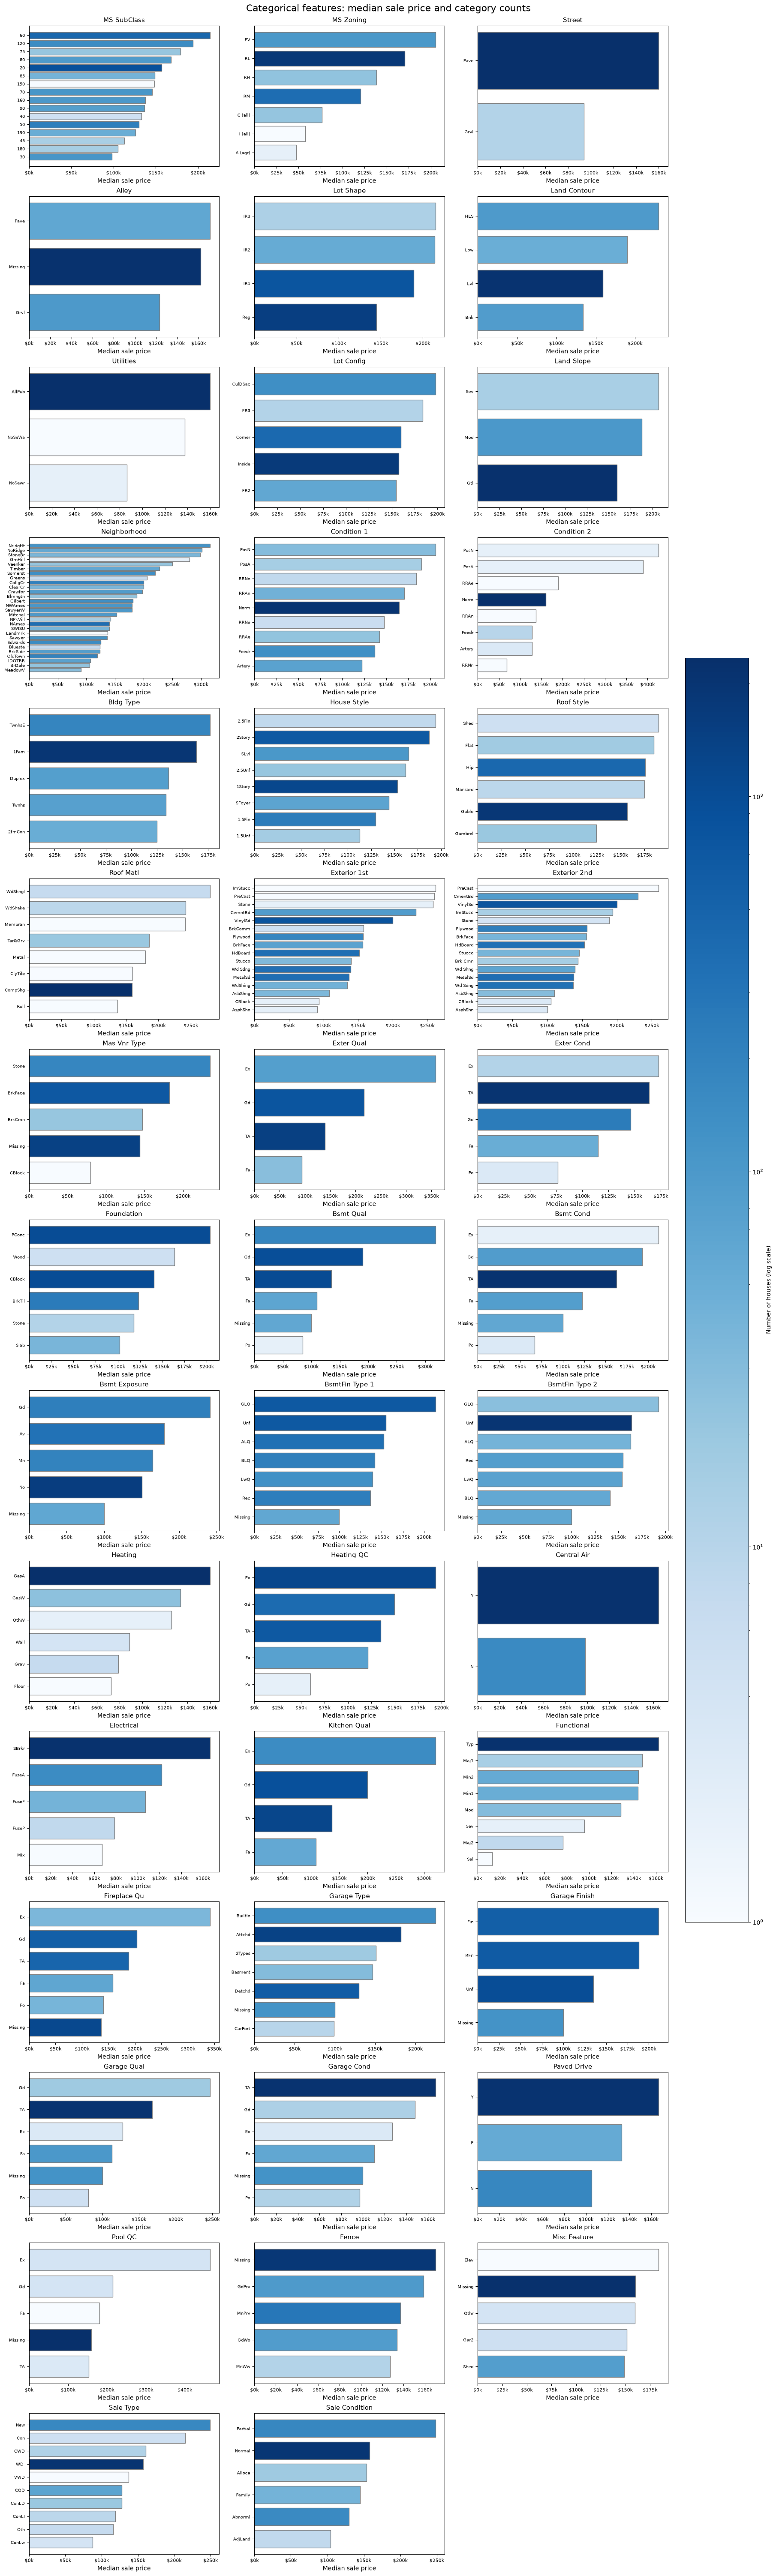

In [ ]:
#Graphical analysis of categorical features
#Generated by ChatGPT

import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

# Summaries for every categorical column
summaries = {
    col: (
        train_df.groupby(col, dropna=False, observed=True)["SalePrice"]
        .agg(["median", "count"])
        .sort_values("median")
    )
    for col in categorical_cols
}

# Shared color scale across all charts
max_count = max(s["count"].max() for s in summaries.values())
norm = LogNorm(vmin=1, vmax=max(2, max_count))
cmap = plt.get_cmap("Blues")

ncols = 3
nrows = math.ceil(len(summaries) / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(18, nrows * 4),
    squeeze=False,
    constrained_layout=True
)

for ax, (col, summary) in zip(axes.flat, summaries.items()):
    labels = [
        "Missing" if pd.isna(value) else str(value)
        for value in summary.index
    ]

    ax.barh(
        range(len(summary)),
        summary["median"],
        color=cmap(norm(summary["count"])),
        edgecolor="grey"
    )

    ax.set_yticks(range(len(summary)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Median sale price")
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"${x / 1000:.0f}k")
    )
    ax.tick_params(axis="x", labelsize=8)

# Hide unused panels
for ax in list(axes.flat)[len(summaries):]:
    ax.set_visible(False)

fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=list(axes.flat),
    label="Number of houses (log scale)",
    shrink=0.5,
    pad=0.02
)

fig.suptitle(
    "Categorical features: median sale price and category counts",
    fontsize=16
)

plt.show()

In [108]:
all_categorical_cols = train_df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
print("Available categorical columns:", all_categorical_cols)

# TODO: add the categories you want to examine.
extra_categorical_cols = ["Kitchen Qual", "Exter Qual", "Garage Type"]
for col in extra_categorical_cols:
    print(f"\nSalePrice by {col}")
    display(train_df.groupby(col, dropna=False, observed=True)["SalePrice"]
            .agg(["count", "median", "mean"]).sort_values("median", ascending=False))



Available categorical columns: ['MS SubClass', 'MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']

SalePrice by Kitchen Qual


,count,median,mean
Kitchen Qual,,,
Ex,150,320000.0,330569.146667
Gd,911,200000.0,209727.105379
TA,1224,137000.0,140235.038399
Fa,59,108500.0,106817.677966



SalePrice by Exter Qual


,count,median,mean
Exter Qual,,,
Ex,82,357950.0,366703.451220
Gd,773,216500.0,227855.197930
TA,1461,139500.0,143564.074606
Fa,28,93775.0,94565.392857



SalePrice by Garage Type


,count,median,mean
Garage Type,,,
BuiltIn,138,225000.0,246470.971014
Attchd,1397,182000.0,200163.161059
2Types,18,151200.0,153088.888889
Basment,30,146750.0,155234.766667
Detchd,631,129900.0,132925.828843
NaN,120,99800.0,105226.108333
CarPort,10,98670.5,103979.100000


In [72]:
# Near-constant categories, not an automatic drop rule.
category_balance = []
for col in all_categorical_cols:
    shares = train_df[col].value_counts(normalize=True, dropna=False)
    category_balance.append({
        "Feature": col,
        "Dominant category": shares.index[0],
        "Dominant share (%)": 100 * shares.iloc[0],
        "Distinct values including missing": train_df[col].nunique(dropna=False)
    })
display(pd.DataFrame(category_balance).sort_values("Dominant share (%)", ascending=False))


,Feature,Dominant category,Dominant share (%),Distinct values including missing
6,Utilities,AllPub,99.872014,3
2,Street,Pave,99.530717,2
39,Pool QC,NaN,99.488055,5
11,Condition 2,Norm,99.146758,8
27,Heating,GasA,98.336177,6
15,Roof Matl,CompShg,98.293515,8
41,Misc Feature,NaN,95.989761,5
8,Land Slope,Gtl,95.051195,3
29,Central Air,Y,93.259386,2
32,Functional,Typ,93.131399,8


**TODO — Q2/Q5:** Which categories differ in median price? How much do their distributions overlap? Cite counts for rare groups. A category with four houses is different from a column where over 99% of all houses share one value. A 99% threshold is a screening guideline; justify any removal and do not remove houses simply because their category is rare.


## 7. Record final feature decisions
Make these decisions from training data. Keep a broad baseline if there is no clear reason to remove a variable. Do not choose features using final test scores.

| Feature | Keep / drop / engineer | Training evidence or domain reason |
|---|---|---|
| Order, PID | Drop | Identifiers; already removed |
| SalePrice | Target | Never included as a predictor |
| MS SubClass | Keep as categorical initially | Numeric-looking house-type code |
| TODO | TODO | TODO |

**TODO:** Explain redundancy, near-constant features and any transformations. Optional age features must have a clear interpretation; check for negative or inconsistent ages.


In [76]:
# TODO: add only columns whose removal you have justified above.
drop_features = ['Condition 2','Utilities', 'Street', 'Pool QC', 'Alley']

X_train = training.drop(columns=["SalePrice"] + drop_features).copy()
y_train = training["SalePrice"].copy()

# Do not inspect or evaluate the reserved test set here.
print("Predictor count:", X_train.shape[1])


Predictor count: 74


just because most houses doesnt have a pool, doesnt mean that if we try to predict the price of one that does have a pool that it doesnt affect the price..... by intution it likley will...

## 8. Define missing-value rules and optional feature engineering
The function below runs identically during training and prediction. It must not learn statistics from its input. Training medians and encoder categories are learned by the pipeline in the next section.



In [82]:

absence_labels = {"Alley": "No alley", "Fence": "No fence", "Garage" : "No garage"}
def prepare_features(X):
    X = X.copy()
    for col, label in absence_labels.items():
        if col in X.columns:
            X[col] = X[col].fillna(label)

    no_garage = X["Garage Area"].eq(0) & X["Garage Cars"].eq(0)
    for col in ["Garage Type", "Garage Finish", "Garage Qual", "Garage Cond"]:
        if col in X.columns:
            X.loc[no_garage, col] = X.loc[no_garage, col].fillna("No garage")

    return X

# Preview only the training transformation.
prepared_train = prepare_features(X_train)
display(prepared_train.head())


,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Lot Shape,Land Contour,Lot Config,Land Slope,Neighborhood,Condition 1,...,3Ssn Porch,Screen Porch,Pool Area,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
381,20,RL,80.0,10400,Reg,Lvl,Inside,Gtl,NWAmes,Norm,...,0,0,0,MnPrv,NaN,0,6,2009,WD,Family
834,60,RL,NaN,28698,IR2,Low,CulDSac,Sev,ClearCr,Norm,...,0,225,0,No fence,NaN,0,6,2009,WD,Abnorml
1898,90,RL,70.0,9842,Reg,Lvl,FR2,Gtl,NAmes,Norm,...,0,0,0,No fence,NaN,0,3,2007,WD,Normal
678,90,RL,60.0,7200,Reg,Lvl,Inside,Gtl,NAmes,Norm,...,0,0,0,No fence,NaN,0,6,2009,WD,Normal
700,190,RM,63.0,7627,Reg,Lvl,Corner,Gtl,OldTown,Artery,...,0,0,0,No fence,NaN,0,10,2009,WD,Normal


## 9. Build one shared preprocessing recipe
The starter recipe uses median imputation and scaling for numerical columns, plus an `Unknown` category and one-hot encoding for categorical columns. One-hot encoding is a simple baseline for ordered ratings too. Scaling is optional for ordinary least squares and unnecessary for trees, but this shared recipe keeps inputs consistent across models.



In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

numeric_cols = prepared_train.select_dtypes(include="number").columns.tolist()
category_cols = prepared_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
assert len(numeric_cols) + len(category_cols) == prepared_train.shape[1], "Check unsupported column types"

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
category_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", category_pipeline, category_cols)
])


## 10. Train the three models
Each model gets an independent copy of the same preprocessing recipe, fitted only on training data. Finish your feature decisions first. Optional model/feature comparisons should use validation or cross-validation within training data, with preprocessing fitted inside each fold.


In [90]:
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}
fitted_models = {}
for name, model in models.items():
    pipeline = Pipeline([
        ("feature_rules", FunctionTransformer(prepare_features, validate=False)),
        ("preprocessing", clone(preprocessor)),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    print("Trained:", name)


Trained: Linear Regression
Trained: Decision Tree
Trained: Random Forest


**TODO:** Record the model settings and why the shared split/features make the comparison fair. Hyperparameter tuning was described as optional in our conversation; verify your brief.


## 11. Final evaluation — enable only when decisions are fixed
Set the switch below to `True` once preprocessing, features and model settings are final. Compare all three models on the same reserved test set. Do not repeatedly modify the workflow to improve these scores.


In [89]:
from sklearn.metrics import mean_squared_error, r2_score

RUN_FINAL_EVALUATION = True  # TODO: set True when ready for final evaluation.
results = None
test_predictions = {}

if RUN_FINAL_EVALUATION:
    X_test = testing.drop(columns=["SalePrice"] + drop_features).copy()
    y_test = testing["SalePrice"].copy()
    rows = []
    for name, pipeline in fitted_models.items():
        predictions = pipeline.predict(X_test)
        test_predictions[name] = predictions
        rows.append({
            "Model": name,
            "Test RMSE ($)": np.sqrt(mean_squared_error(y_test, predictions)),
            "Test R²": r2_score(y_test, predictions)
        })
    results = pd.DataFrame(rows).sort_values("Test RMSE ($)")
    display(results)
else:
    print("Test set remains reserved. Complete the TODO decisions first.")


c:\Users\rober\Downloads\ML_ass\ML_assignment_1\mlVENV1\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [13, 26, 27, 36] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\rober\Downloads\ML_ass\ML_assignment_1\mlVENV1\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [13, 26, 27, 36] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\rober\Downloads\ML_ass\ML_assignment_1\mlVENV1\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [13, 26, 27, 36] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Model,Test RMSE ($),Test R²
2,Random Forest,26777.992462,0.910564
0,Linear Regression,35234.068211,0.845160
1,Decision Tree,35656.791405,0.841422


## 12. Interpret errors and limitations


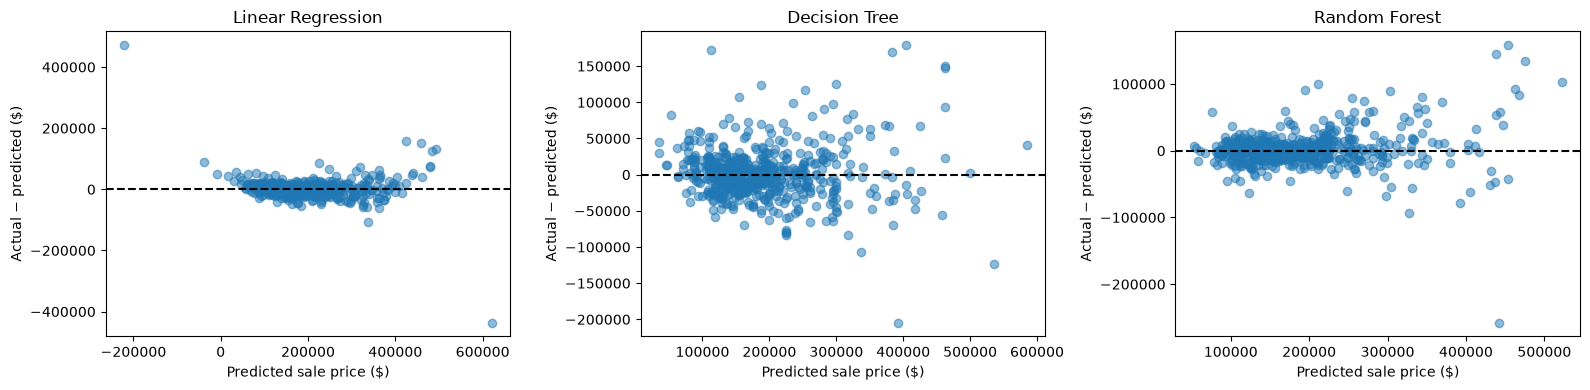

In [88]:
if RUN_FINAL_EVALUATION:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (name, predictions) in zip(axes, test_predictions.items()):
        ax.scatter(predictions, y_test - predictions, alpha=0.5)
        ax.axhline(0, color="black", linestyle="--")
        ax.set(title=name, xlabel="Predicted sale price ($)", ylabel="Actual − predicted ($)")
    plt.tight_layout()
    plt.show()
